## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

1. **Critical Care Protocols:** "What is the protocol for managing sepsis in a critical care unit?"

2. **General Surgery:** "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"

3. **Dermatology:** "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"

4. **Neurology:** "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"


### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## Installing and Importing Necessary Libraries and Dependencies

In [4]:
# Install required libraries for LangChain, vector stores, PDF loading, tokenization, and evaluation
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30
# Upgrade specific LangChain components to their latest compatible versions
!pip install -q --upgrade langchain_openai langchain langchain_community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [5]:
# Import core Python libraries
import os         # For operating system interactions, like environment variables
import json       # For working with JSON data
import pandas as pd # For data manipulation and analysis, particularly with DataFrames

In [8]:
# Define the name of the configuration file
file_name = 'config.json'
# Open and load the configuration file to extract OpenAI API keys
with open(file_name, 'r') as file:
    config = json.load(file)
    OPENAI_API_KEY = config['OPENAI_API_KEY']  # Extract OpenAI API key
    OPENAI_API_BASE = config['OPENAI_API_BASE'] # Extract OpenAI API base URL

# Store the API key and base URL as environment variables for secure access by libraries
os.environ['OPENAI_API_KEY']= OPENAI_API_KEY
os.environ['OPENAI_API_BASE'] = OPENAI_API_BASE

In [9]:
# Import necessary OpenAI libraries
from openai import OpenAI          # The main OpenAI Python client
from langchain_openai import ChatOpenAI # LangChain integration for OpenAI chat models

In [10]:
# Define a function to get a response from an OpenAI chat model
def get_response(question):
  # Initialize the ChatOpenAI model with specific parameters
  llm = ChatOpenAI(model = "gpt-4o-mini", temperature=0.3, max_tokens=1000)
  # Prepare the message in the format expected by the chat model (user role)
  messages = [
       ("user", question),
      ]
  # Invoke the language model with the prepared messages
  response = llm.invoke(messages)
  # Return the content of the model's response
  return response.content

## Question Answering using LLM

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

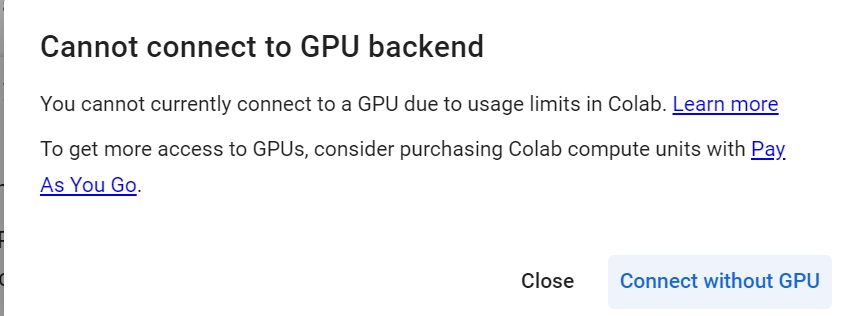

#### Downloading and Loading the model

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [11]:
# Call the get_response function with a specific medical question about sepsis protocol
get_response("What is the protocol for managing sepsis in a critical care unit?")

'Managing sepsis in a critical care unit involves a systematic approach to early identification, aggressive treatment, and ongoing monitoring. The Surviving Sepsis Campaign provides guidelines that are widely used in clinical practice. Here is an overview of the protocol for managing sepsis:\n\n### 1. **Early Recognition**\n   - **Screening:** Use screening tools to identify patients at risk for sepsis. Look for signs of infection and organ dysfunction.\n   - **Assessment:** Monitor vital signs, laboratory results, and clinical symptoms. Key indicators include fever, tachycardia, tachypnea, altered mental status, and hypotension.\n\n### 2. **Initial Resuscitation (within the first hour)**\n   - **Fluid Resuscitation:** Administer intravenous (IV) fluids (30 mL/kg of crystalloid) for hypotension or lactate ≥ 4 mmol/L. Monitor for fluid responsiveness.\n   - **Vasopressors:** If hypotension persists after fluid resuscitation, initiate vasopressors (e.g., norepinephrine) to maintain mean 

### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [10]:
# Call the get_response function with a specific medical question about appendicitis symptoms and treatment
get_response('What are the common symptoms for appendicitis, and can it be cured via medicine?')

'Common symptoms of appendicitis include:\n\n1. **Abdominal Pain**: Typically starts near the belly button and then moves to the lower right abdomen.\n2. **Loss of Appetite**: A sudden loss of hunger is common.\n3. **Nausea and Vomiting**: Often follows the abdominal pain.\n4. **Fever**: Mild fever may occur, usually around 99°F to 102°F (37.2°C to 38.9°C).\n5. **Constipation or Diarrhea**: This can occur as symptoms progress.\n6. **Abdominal Swelling**: The abdomen may become tender and swollen.\n\nAs for treatment, while some mild cases might be managed with antibiotics, appendicitis is most commonly treated with surgical removal of the appendix, known as an appendectomy. Surgery is generally considered the most effective and definitive treatment, especially to prevent complications like rupture, which can lead to serious infections. If you suspect appendicitis, it is essential to seek medical attention promptly.'

### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [11]:
# Call the get_response function with a specific medical question about patchy hair loss
get_response('What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?')

"Sudden patchy hair loss, often referred to as alopecia areata, can manifest as localized bald spots on the scalp and occasionally other areas of the body. Here are some effective treatments and solutions for managing this condition, along with potential causes:\n\n### **Effective Treatments:**\n\n1. **Corticosteroids:**\n   - Topical corticosteroids are commonly prescribed to reduce inflammation and promote hair regrowth. Injections of corticosteroids into the affected areas can also be effective for more severe cases.\n\n2. **Minoxidil (Rogaine):**\n   - This over-the-counter topical treatment is applied directly to the scalp. It may encourage hair regrowth in some individuals, though results can vary.\n\n3. **Anthralin:**\n   - A topical medication that can help stimulate hair growth by irritating the skin and altering immune function.\n\n4. **Diphencyprone (DPCP):**\n   - A form of immunotherapy that involves applying a chemical to the scalp to induce an allergic reaction, promptin

### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [12]:
# Call the get_response function with a specific medical question about brain injury treatments
get_response('What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?')

"The treatment for brain injuries, which can result from trauma, strokes, tumors, or other causes, varies significantly based on the severity, type, and specific area of the brain affected. Here are some general approaches to managing brain injuries and associated impairments:\n\n1. **Immediate Medical Care**:\n   - **Emergency Treatment**: In the case of severe injuries, immediate medical attention is critical. This may involve surgery to alleviate pressure on the brain or repair structural damage.\n   - **Stabilization**: Ensuring the patient is stable, maintaining airway, breathing, and circulation.\n\n2. **Medication**:\n   - **Anti-inflammatory Drugs**: To reduce swelling in the brain.\n   - **Anticonvulsants**: To prevent seizures that can occur after a brain injury.\n   - **Pain Management**: Analgesics to manage headache or pain.\n\n3. **Rehabilitation**:\n   - **Physical Therapy**: To improve motor function and mobility.\n   - **Occupational Therapy**: To help individuals rega

#Comments and resposes observations:
- Answers are detailed but general.
- Based on training knowledge not a verified source.
- Risk of hallucination(confident but potentially inacurate medical informations).

## Question Answering using LLM with Prompt Engineering

In [12]:
# Create a function that generates a response using prompt engineering
# This function takes a question as a parameter and returns the content of the response.
# The LLM is guided by adding a system prompt to the message for a more specific role.
def get_response_with_prompt(question):
   # Initialize the ChatOpenAI model with specific parameters
   llm = ChatOpenAI(model = "gpt-4o-mini", temperature=0.3, max_tokens=1000)
   # Prepare messages, including a system prompt to set the AI's persona and instructions
   messages = [
       ('system', 'Your are a medical expert. Be precise and structured. Acknowledge uncertainity instead of halucinating. Format answers clearly for healthcare professionals.'),
       ('user', question)
   ]

   # Invoke the language model with the structured messages
   response = llm.invoke(messages)
   # Return the content of the model's response
   return response.content

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [38]:
# Call the get_response_with_prompt function with a medical question about sepsis protocol
get_response_with_prompt('What is the protocol for managing sepsis in a critical care unit?')

'Managing sepsis in a critical care unit involves a structured approach that follows established guidelines, such as those from the Surviving Sepsis Campaign. The protocol can be summarized in the following key steps:\n\n### 1. **Early Recognition**\n   - **Identify Symptoms**: Monitor for signs of sepsis, including fever, tachycardia, tachypnea, altered mental status, and hypotension.\n   - **Use of Scoring Systems**: Utilize tools like the Sequential Organ Failure Assessment (SOFA) score or quick SOFA (qSOFA) to assess the severity.\n\n### 2. **Initial Resuscitation**\n   - **Fluid Resuscitation**: Administer intravenous fluids (crystalloids) promptly, typically 30 mL/kg within the first 3 hours.\n   - **Hemodynamic Monitoring**: Use invasive monitoring (e.g., arterial line, central venous pressure) if necessary to guide fluid therapy.\n\n### 3. **Antibiotic Therapy**\n   - **Early Administration**: Administer broad-spectrum antibiotics within 1 hour of sepsis recognition.\n   - **So

### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [15]:
# Call the get_response_with_prompt function with a medical question about appendicitis
get_response_with_prompt('What are the common symptoms for appendicitis, and can it be cured via medicine?')

'### Common Symptoms of Appendicitis\n\nAppendicitis is characterized by a range of symptoms that may vary among individuals. Common symptoms include:\n\n1. **Abdominal Pain**:\n   - Initial pain often starts around the umbilical region (periumbilical).\n   - It typically shifts to the right lower quadrant (RLQ) as the condition progresses.\n\n2. **Nausea and Vomiting**:\n   - May occur after the onset of abdominal pain.\n\n3. **Loss of Appetite**:\n   - Commonly reported by patients prior to or following the onset of pain.\n\n4. **Fever**:\n   - Mild fever may be present, which can escalate as the condition worsens.\n\n5. **Changes in Bowel Movements**:\n   - Some patients may experience constipation or diarrhea.\n\n6. **Rebound Tenderness**:\n   - Increased pain upon release of pressure in the RLQ upon palpation.\n\n7. **Guarding**:\n   - Involuntary tensing of the abdominal muscles upon palpation.\n\n### Treatment Options\n\n- **Surgical Intervention**:\n  - **Appendectomy** (surgic

### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [16]:
# Call the get_response_with_prompt function with a medical question about patchy hair loss
get_response_with_prompt('What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?')

'### Sudden Patchy Hair Loss: Overview\n\n**Clinical Presentation:**\n- Sudden patchy hair loss, often referred to as alopecia areata, manifests as localized bald spots on the scalp or other areas of the body.\n\n### Possible Causes\n\n1. **Alopecia Areata:**\n   - An autoimmune disorder that targets hair follicles.\n   - Hereditary predisposition can play a role.\n\n2. **Stress or Trauma:**\n   - Physical or emotional stress can lead to temporary hair loss (e.g., telogen effluvium).\n\n3. **Infections:**\n   - Fungal infections (e.g., tinea capitis) can cause hair loss.\n\n4. **Nutritional Deficiencies:**\n   - Deficiencies in iron, zinc, biotin, or protein may contribute.\n\n5. **Scalp Conditions:**\n   - Skin disorders like psoriasis or dermatitis.\n\n6. **Medications:**\n   - Certain drugs (e.g., chemotherapy agents, anticoagulants) can result in hair loss.\n\n7. **Endocrine Disorders:**\n   - Hormonal imbalances (e.g., thyroid issues) and autoimmune diseases.\n\n### Effective Trea

### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [17]:
# Call the get_response_with_prompt function with a medical question about brain injury treatments
get_response_with_prompt('What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?')

"The treatment for a person who has sustained a physical injury to brain tissue, such as a traumatic brain injury (TBI), is multifaceted and typically requires a multidisciplinary approach. The specific treatment plan may vary based on the severity of the injury, the specific areas of the brain affected, and the individual's overall health. Here are the general treatment strategies:\n\n### Immediate Treatment\n1. **Emergency Care**\n   - Stabilization of vital signs.\n   - Neuroimaging (CT or MRI) to assess the extent of injury.\n   - Intracranial pressure monitoring if indicated.\n\n2. **Surgical Interventions (if necessary)**\n   - Decompressive craniectomy for significant swelling.\n   - Hematoma evacuation for subdural or epidural hematomas.\n   - Repair of skull fractures if they compromise function.\n\n### Medical Management\n1. **Medications**\n   - Corticosteroids to reduce inflammation (consider risks vs. benefits).\n   - Anticonvulsants to prevent seizures.\n   - Pain managem

#Comments and Observations:
- More structured and precise than simple LLM.
- Format tailored for healthcare professionals.
- Subtle uncertainty acknowledgement present.
- Still on training knowledge (it might hallucinate).

## Data Preparation for RAG

### Loading the Data

In [13]:
# Import PyMuPDFLoader to load PDF documents
from langchain_community.document_loaders import PyMuPDFLoader
# Define the document loader, pointing to the medical diagnosis manual PDF file
loader = PyMuPDFLoader('medical_diagnosis_manual.pdf')
# Load the documents from the PDF file
documents = loader.load()

### Data Overview

In [14]:
# Print the total number of pages/documents loaded
print(len(documents))
# Print the content of a specific page (page 1000) to verify text readability
print(documents[1000].page_content)

4114
Increased anion gap is most commonly caused by metabolic acidosis in which negatively charged acids
—mostly ketones, lactate, sulfates, or metabolites of methanol, ethylene glycol, and salicylate—consume
(are buffered by) HCO3-. Other causes of increased anion gap include hyperalbuminemia and uremia
(increased anions) and hypocalcemia or hypomagnesemia (decreased cations).
Decreased anion gap is unrelated to metabolic acidosis but is caused by hypoalbuminemia (decreased
anions); hypercalcemia, hypermagnesemia, lithium intoxication, and hypergammaglobulinemia (increased
cations); or hyperviscosity or halide (bromide or iodide) intoxication. The effect of low albumin can be
accounted for by adjusting the normal range for the anion gap 2.5 mEq/L upward for every 1-g/dL fall in
albumin.
Negative anion gap occurs rarely as a laboratory artifact in severe cases of hypernatremia,
hyperlipidemia, and bromide intoxication.
The delta gap: The difference between the patient's anion gap and t

### Data Chunking

In [15]:
# Import RecursiveCharacterTextSplitter for text chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter
# Initialize the text splitter with a chunk size of 1000 characters and an overlap of 200 characters
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
# Chunk the loaded documents into smaller, manageable pieces
split_docs = splitter.split_documents(documents)
# Print the total number of chunks created
print(len(split_docs))
# Print the content of a specific chunk (chunk 500) to inspect its content
split_docs[500].page_content

18050


"elemental zinc ranging from 100 to 150 mg/day for prolonged periods interferes with copper metabolism\nand causes low blood copper levels, RBC microcytosis, neutropenia, and impaired immunity; higher\ndoses should be given only for short periods of time and the patient should be followed closely. Ingesting\nlarger amounts (200 to 800 mg/day), usually by consuming acidic food or drink from a galvanized (zinc-\ncoated) container, can cause anorexia, vomiting, and diarrhea. Metal fume fever, also called brass-\nfounders' ague or zinc shakes, is caused by inhaling industrial zinc oxide fumes; it results in neurologic\ndamage. Symptoms usually resolve after 12 to 24 h in a zinc-free environment.\nThe Merck Manual of Diagnosis & Therapy, 19th Edition\nChapter 5. Mineral Deficiency & Toxicity\n107\namadousadialloh@gmail.com\nEVILOZ5H0N\nThis file is meant for personal use by amadousadialloh@gmail.com only.\nSharing or publishing the contents in part or full is liable for legal action."

### Embedding

In [16]:
# Import OpenAIEmbeddings for creating numerical representations of text
from langchain_openai import OpenAIEmbeddings
# Initialize the embedding model
embeddings = OpenAIEmbeddings()

### Vector Database

In [18]:
#import Chroma to store the embedded chunks of documents
from langchain_community.vectorstores import Chroma
vectorstore = Chroma.from_documents(split_docs, embeddings)

### Retriever

In [19]:
# Define how to search the vector database: 'similarity' search with 'k' (top 5) results
retriever = vectorstore.as_retriever(search_tyhpe='similarity', search_kwargs={'k': 5})

### Response Function

In [20]:
# Define a function to get a response from a RAG (Retrieval Augmented Generation) system
def get_response_rag(question):
    # Initialize the ChatOpenAI model for generating responses
    llm = ChatOpenAI(model = "gpt-4o-mini", temperature=0.3, max_tokens=1000)
    # Retrieve relevant documents based on the user's question
    docs = retriever.invoke(question)
    # Combine the content of the retrieved documents into a single context string
    context = "\n\n".join([doc.page_content for doc in docs])
    # Prepare messages for the LLM, including the retrieved context
    messages = [
        ('system', f"Use the following context to answer the question.\nContext: {context}"),
        ('human', question)
    ]
    # Invoke the language model to generate a response using the provided context
    response = llm.invoke(messages)
    # Return the content of the model's response
    return response.content

## Question Answering using RAG

### Question 1: What is the protocol for managing sepsis in a critical care unit?

In [21]:
# Call the get_response_rag function with a medical question about sepsis protocol
get_response_rag('What is the protocol for managing sepsis in a critical care unit?')

"The protocol for managing sepsis in a critical care unit includes the following key components:\n\n1. **Fluid Resuscitation**: Administer 0.9% normal saline until central venous pressure (CVP) reaches 8 mm Hg (10 cm H2O) or pulmonary artery occlusion pressure (PAOP) reaches 12 to 15 mm Hg. Oliguria with hypotension is not a contraindication to vigorous fluid resuscitation.\n\n2. **Oxygen Therapy**: Provide supplemental oxygen to maintain adequate oxygenation.\n\n3. **Broad-Spectrum Antibiotics**: Initiate prompt empiric antibiotic therapy after obtaining cultures from blood, body fluids, and wound sites. Antibiotic selection should be based on the suspected source of infection, clinical setting, and knowledge of common organisms and their sensitivity patterns.\n\n4. **Drainage and Surgical Intervention**: Identify and drain abscesses and excise any necrotic tissue as necessary.\n\n5. **Blood Glucose Management**: Normalize blood glucose levels using a continuous IV insulin infusion, t

### Question 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [ ]:
# Call the get_response_rag function with a medical question about appendicitis
get_response_rag(': What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?')

### Question 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [ ]:
# Call the get_response_rag function with a medical question about patchy hair loss
get_response_rag('What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?')

### Question 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [ ]:
# Call the get_response_rag function with a medical question about brain injury treatments
get_response_rag('What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?')

#Comment and Observations:
- With RAG, the answers are more precise, like "Gentamicin or tobramycin 5.1 mg/kg IV once daily" in question 1 which was not specified in simple LLM or LLM with prompt.
- We can see that the infos come from the actual pdf.


## Output Evaluation

In [32]:
# Create a function to evaluate the output using an LLM as a judge.
def evaluate_response(question, answer, metric):
  # Initialize the ChatOpenAI model for evaluation
  llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.9)
  # Construct a prompt for the LLM to rate the answer based on a specific metric
  prompt = f""" Rate theis answer strictly on {metric} from 1-3
  {metric} definitions:
  - Groundedness: Is the answer based on verifiable source? (1=no source, 2=partial, 3=verified source)
  - Relevance: Does it answer the question? (1=off topic, 2=partial, 3=fully answers)
  - Context Precision: How specific and detailed? (1=vague, 2=moderate, 3=precise)

  Question: {question}
  Answer: {answer}

  Reply only with a single number: 1, 2, or 3"""

  # Invoke the LLM with the prompt
  response = llm.invoke([('user', prompt)])
  # Convert the LLM's response (which should be a single number) to an integer and return it
  return int(response.content.strip())

#### **Evaluation 1: Base Prompt Response Evaluation**

In [33]:
# Define a list of questions for evaluation
questions = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "What are the common symptoms for appendicitis, and can it be cured via medicine?",
    "What are the effective treatments for sudden patchy hair loss?",
    "What treatments are recommended for physical injury to brain tissue?"
]

# Define the metrics to evaluate (Groundedness, Relevance, Context Precision)
metrics = ["Groundedness", "Relevance", "Context Precision"]

# Initialize a list to store evaluation results for the baseline LLM
baseline_results = []
# Iterate through each question
for question in questions:
    # Get the answer from the baseline LLM
    answer = get_response(question)
    # Evaluate the answer against each metric and store the scores
    scores = [evaluate_response(question, answer, metric) for metric in metrics]
    baseline_results.append(scores)

# Create a Pandas DataFrame from the evaluation results for organized display
df_baseline = pd.DataFrame(baseline_results,
    columns=metrics,
    index=["Sepsis", "Appendicitis", "Hair Loss", "Brain Injury"])
# Print the DataFrame containing the baseline evaluation scores
print(df_baseline)

              Groundedness  Relevance  Context Precision
Sepsis                   3          3                  3
Appendicitis             3          3                  3
Hair Loss                3          3                  3
Brain Injury             3          3                  3


#### **Evaluation 2: Prompt Engineering Response Evaluation**

In [28]:
# Define a list of questions for evaluation
questions = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "What are the common symptoms for appendicitis, and can it be cured via medicine?",
    "What are the effective treatments for sudden patchy hair loss?",
    "What treatments are recommended for physical injury to brain tissue?"
]

# Define the metrics to evaluate (Groundedness, Relevance, Context Precision)
metrics = ["Groundedness", "Relevance", "Context Precision"]

# Initialize a list to store evaluation results for the prompt-engineered LLM
baseline_results = []
# Iterate through each question
for question in questions:
    # Get the answer from the LLM with prompt engineering
    answer = get_response_with_prompt(question)
    # Evaluate the answer against each metric and store the scores
    scores = [evaluate_response(question, answer, m) for m in metrics]
    baseline_results.append(scores)

# Create a Pandas DataFrame from the evaluation results for organized display
df_baseline = pd.DataFrame(baseline_results,
    columns=metrics,
    index=["Sepsis", "Appendicitis", "Hair Loss", "Brain Injury"])
# Print the DataFrame containing the prompt engineering evaluation scores
print(df_baseline)

              Groundedness  Relevance  Context Precision
Sepsis                   3          3                  3
Appendicitis             3          3                  3
Hair Loss                3          3                  3
Brain Injury             3          3                  3


#### **Evaluation 3: RAG Response Evaluation**

In [29]:
# Define a list of questions for evaluation
questions = [
    "What is the protocol for managing sepsis in a critical care unit?",
    "What are the common symptoms for appendicitis, and can it be cured via medicine?",
    "What are the effective treatments for sudden patchy hair loss?",
    "What treatments are recommended for physical injury to brain tissue?"
]

# Define the metrics to evaluate (Groundedness, Relevance, Context Precision)
metrics = ["Groundedness", "Relevance", "Context Precision"]

# Initialize a list to store evaluation results for the RAG system
baseline_results = []
# Iterate through each question
for question in questions:
    # Get the answer from the RAG system
    answer = get_response_rag(question)
    # Evaluate the answer against each metric and store the scores
    scores = [evaluate_response(question, answer, m) for m in metrics]
    baseline_results.append(scores)

# Create a Pandas DataFrame from the evaluation results for organized display
df_baseline = pd.DataFrame(baseline_results,
    columns=metrics,
    index=["Sepsis", "Appendicitis", "Hair Loss", "Brain Injury"])
# Print the DataFrame containing the RAG system evaluation scores
print(df_baseline)

              Groundedness  Relevance  Context Precision
Sepsis                   3          3                  3
Appendicitis             3          3                  3
Hair Loss                3          3                  3
Brain Injury             3          3                  3


#Comment and observations:
Using an llm-as-judge, the score is equal for all the responses. A good approach might be to fine tune some parameters.
By analyzing the responses visually, i will conclude as follow:

- Baseline LLM scores 1 on groundedness because we can't verify the source.
- Prompt engineering scores better than Baseline llm because even without external data, better instructions improve output quality. We could also verify the source(surviving camapign website).
- RAG scores 3 because we can verify the source and hallucination risk is reduced since answers are grounded in the Merck Manual file. Overall, healthcare provider should use RAG because response comes from a verified source with real medical informations.

## Actionable Insights and Business Recommendations

###- Reducing Information Overload:
RAG enables healthcare professionals to retrieve only the most relevant medical information instantly, reducing time spent searching through thousands of pages and supporting faster clinical decision-making.
###- Deployment Awareness:
Before deploying this system in a clinical setting, healthcare organizations should be aware that hallucination risk, while reduced, is not eliminated. Human expert review of AI-generated recommendations remains essential.
###- Continuous Improvement:
 To maintain accuracy and reliability, the underlying knowledge base should be regularly updated with the latest medical guidelines and research, ensuring the system reflects current standards of care.

<font size=6 color='#4682B4'>Power Ahead</font>
___